In [146]:
import os
import re
import random

In [179]:
import pandas as pd

data = pd.read_csv('competition_data.csv')
submission = pd.read_csv('submission.csv')
submission_aux = pd.read_csv('submission.csv')

In [180]:
submission

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle
0,32933,2020-04-22T03:12:40Z,11145402699,OS X 10.15.4 [x86 8],AR,unknown,(Your Love Keeps Lifting Me) Higher & Higher,Jackie Wilson,The Ultimate Jackie Wilson,spotify:track:4TBBPZks71c60whhq0PgdP,trackdone,True
1,32713,2020-04-17T19:40:02Z,11145402699,OS X 10.15.4 [x86 8],AR,unknown,Soul Sacrifice,Santana,Santana (Legacy Edition),spotify:track:4e0GkgtMPZFt41Ua8PlHQL,fwdbtn,True
2,90799,2017-11-22T13:46:08Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Voyage voyage,Desireless,François,spotify:track:2d8D7uk3tbAThjRkdfrx9c,fwdbtn,True
3,30990,2020-03-22T18:15:46Z,11145402699,OS X 10.15.1 [x86 8],AR,unknown,Penny Lane - Remastered 2009,The Beatles,Magical Mystery Tour,spotify:track:1h04XMpzGzmAudoI6VHBgA,fwdbtn,True
4,110120,2018-03-10T17:54:56Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,"Breaking Free - From ""High School Musical""",High School Musical Cast,The Very Best West End Musicals - This Century,spotify:track:5QQOO2zF8vyyfICow4r5Cq,clickrow,True
...,...,...,...,...,...,...,...,...,...,...,...,...
25032,14029,2021-12-04T14:59:21Z,11145402699,OS X 12.0.1 [arm 2],AR,unknown,Lucky Nights,Lucas Estrada,Lucky Nights,spotify:track:2nTePC0sPbtVnnjYgPz7ff,fwdbtn,True
25033,110726,2018-03-30T02:58:16Z,11145402699,OS X 10.13.3 [x86 8],AR,NaN,Put On Your Sunday Clothes,Jerry Herman,"Hello, Dolly!",spotify:track:1M2zeYn9S4zorVjz05oZw1,trackdone,False
25034,86934,2017-09-10T15:48:19Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,trackdone,True
25035,84199,2017-07-30T21:49:52Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Tragedy,Bee Gees,Spirits Having Flown,spotify:track:04waBn6uK4Af8udH2KqQri,clickrow,True


In [181]:
data

,Unnamed: 0,ts,username,platform,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET
0,110163,2018-03-11T05:05:45Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,clickrow,False,False
1,66026,2023-06-05T10:42:33Z,11145402699,ios,AR,unknown,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,trackdone,True,False
2,116790,2018-07-01T02:04:51Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,unknown,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,trackdone,True,True
3,18431,2019-09-08T04:58:07Z,11145402699,"iOS 12.4 (iPhone8,1)",AR,unknown,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,trackdone,False,True
4,82941,2017-07-13T18:13:52Z,11145402699,"iOS 11.0 (iPhone8,1)",AR,NaN,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,trackdone,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06T20:31:14Z,11145402699,"iOS 10.2.1 (iPad6,8,1)",AR,NaN,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,trackdone,True,False
100140,12585,2021-11-03T21:06:07Z,11145402699,"iOS 15.1 (iPhone12,3)",AR,unknown,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,trackdone,True,False
100141,93960,2022-01-14T01:13:42Z,11145402699,"iOS 15.2 (iPhone12,3)",AR,unknown,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,trackdone,True,False
100142,74339,2024-05-01T17:51:16Z,11145402699,ios,AR,NaN,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,trackdone,True,False


In [182]:
#eliminamos datos particulares de Chona, son siempre los mismos, y los que consideramos irrelevanets
data = data.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])
submission = submission.drop(columns=['username', 'conn_country', 'user_agent_decrypted'])

In [183]:
# del timestamp, solo nos interesa distinguir hora, el dia de la semana, el mes y el año

data['ts'] = pd.to_datetime(data['ts'])
submission['ts'] = pd.to_datetime(submission['ts'])

# Extraer la hora
data['hour'] = data['ts'].dt.hour
submission['hour'] = submission['ts'].dt.hour

# Extraer el día de la semana (0 es lunes, 6 es domingo)
data['day_of_week'] = data['ts'].dt.dayofweek
submission['day_of_week'] = submission['ts'].dt.dayofweek

# Extraer el mes
data['month'] = data['ts'].dt.month
submission['month'] = submission['ts'].dt.month

# Extraer el año
data['year'] = data['ts'].dt.year - 2000
submission['year'] = submission['ts'].dt.year - 2000

In [184]:
# del dispositivo, solo queremos saber si se reprodujo en celular (iphone) o no
data['is_iphone'] = data['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)
submission['is_iphone'] = submission['platform'].apply(lambda x: 1 if ('ios' in x or 'iOS' in x) else 0)

# dropeamos platform
data = data.drop(columns=['platform'])
submission = submission.drop(columns=['platform'])

In [185]:
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone
0,110163,2018-03-11 05:05:45+00:00,Crazy For U,Big Time Rush,24/seven,spotify:track:3jFfr89lnSmb4QBtfG8JBP,clickrow,False,False,5,6,3,18,1
1,66026,2023-06-05 10:42:33+00:00,Nada Personal - Remasterizado 2007,Soda Stereo,Me Verás Volver (Hits & Más),spotify:track:09TTeexnlKewZdjOak2sV2,trackdone,True,False,10,0,6,23,1
2,116790,2018-07-01 02:04:51+00:00,Good Times,CHIC,Risqué,spotify:track:0G3fbPbE1vGeABDEZF0jeG,trackdone,True,True,2,6,7,18,1
3,18431,2019-09-08 04:58:07+00:00,Verano del 92,Los Piojos,3er Arco,spotify:track:1NXvuBAq48QrxRFQZVmORQ,trackdone,False,True,4,6,9,19,1
4,82941,2017-07-13 18:13:52+00:00,Simpatico,Ekko Park,Simpatico,spotify:track:2gYJY0sIx1ErgTIha2nPRg,trackdone,True,False,18,3,7,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,78756,2017-04-06 20:31:14+00:00,Losing My Religion,R.E.M.,In Time: The Best Of R.E.M. 1988-2003,spotify:track:12axV6NUqaYH3yFUWwArzr,trackdone,True,False,20,3,4,17,1
100140,12585,2021-11-03 21:06:07+00:00,Cerca De La Revolucion,Charly García,Piano Bar,spotify:track:66grIvFLGrI4tNhggO2DAd,trackdone,True,False,21,2,11,21,1
100141,93960,2022-01-14 01:13:42+00:00,A Los Jóvenes De Ayer - Remastered 2012,Serú Girán,Bicicleta,spotify:track:6YAl320SfxLO4rVIZTFKqG,trackdone,True,False,1,4,1,22,1
100142,74339,2024-05-01 17:51:16+00:00,heat not hot,Serengeti,heat not hot,spotify:track:0rKLO1hXpmoIthQgJKoczN,trackdone,True,False,17,2,5,24,1


In [186]:
#antes de seguir con operaciones por columna, separamos validation y train
# la idea es que train tenga 80% de datos de cada año, y val el resto
train_parts = []
val_parts = []

for year, group in data.groupby('year'):
    group = group.sort_values('ts')  # mantener orden cronológico dentro del año
    split_idx = int(len(group) * 0.8)
    train_parts.append(group.iloc[:split_idx])
    val_parts.append(group.iloc[split_idx:])

train_data = pd.concat(train_parts).sort_values('ts').reset_index(drop=True)
val_data = pd.concat(val_parts).sort_values('ts').reset_index(drop=True)

In [187]:
train_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,fwdbtn,True,True,18,4,6,14,1
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,NaN,False,True,20,6,6,14,1
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,fwdbtn,False,True,20,6,6,14,1
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,fwdbtn,False,True,20,6,6,14,1
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,NaN,False,True,21,3,9,14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,trackdone,True,False,18,1,4,24,1
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,trackdone,True,True,18,1,4,24,1
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,fwdbtn,True,True,18,1,4,24,1
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,fwdbtn,True,True,18,1,4,24,1


In [188]:
submission = submission.sort_values('ts').reset_index(drop=True)

In [108]:
# # Aplicar One-Hot Encoding a razon de reproduccion
# train_reason_start_encoded = pd.get_dummies(train_data['reason_start'], prefix='reason', dummy_na=False)
# val_reason_start_encoded = pd.get_dummies(val_data['reason_start'], prefix='reason', dummy_na=False)
# submission_reason_start_encoded = pd.get_dummies(submission['reason_start'], prefix='reason', dummy_na=False)

# # # Concatenar el DataFrame original con el nuevo DataFrame de variables codificadas
# train_data = pd.concat([train_data, train_reason_start_encoded], axis=1)
# val_data = pd.concat([val_data, val_reason_start_encoded], axis=1)
# submission = pd.concat([submission, submission_reason_start_encoded], axis=1)

# # # Dropear la columna original
# train_data = train_data.drop(columns=['reason_start'])
# val_data = val_data.drop(columns=['reason_start'])
# submission = submission.drop(columns=['reason_start'])

In [189]:
# #al analizar los df, vemos que a validation le falta columna reason_unknown
val_data['reason_unknown'] = False
val_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone,reason_unknown
0,74922,2014-09-04 21:46:32+00:00,Sonnentanz,Klangkarussell,Netzwerk,spotify:track:1RTVBt6wWtWs2qiRVnlzLM,NaN,False,True,21,3,9,14,1,False
1,74925,2014-09-04 21:48:51+00:00,Run,Ludovico Einaudi,Ludovico Einaudi: In a time lapse,spotify:track:7GNBEiGfBrp88IfxiiHbeK,NaN,False,True,21,3,9,14,1,False
2,74945,2016-06-23 21:13:11+00:00,NaN,NaN,NaN,NaN,clickrow,False,True,21,3,6,16,0,False
3,74946,2016-06-23 22:23:36+00:00,NaN,NaN,NaN,NaN,clickrow,False,False,22,3,6,16,0,False
4,74947,2016-06-24 01:10:47+00:00,NaN,NaN,NaN,NaN,clickrow,False,False,1,4,6,16,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20029,74911,2024-05-23 17:24:56+00:00,The Tide Is High,Blondie,Atomic/Atomix,spotify:track:52Rp3xBJFYYdmpgzDy0Quf,trackdone,True,False,17,3,5,24,1,False
20030,74912,2024-05-23 17:28:33+00:00,The Less I Know The Better,Tame Impala,Currents,spotify:track:6K4t31amVTZDgR3sKmwUJJ,trackdone,True,False,17,3,5,24,1,False
20031,74913,2024-05-23 23:44:01+00:00,Pink + White,Frank Ocean,Blonde,spotify:track:3xKsf9qdS1CyvXSMEid6g8,trackdone,True,False,23,3,5,24,1,False
20032,74914,2024-05-23 23:50:25+00:00,Still Got The Blues,Gary Moore,Still Got The Blues,spotify:track:0DnGfA1r8pAssJCuq4ojla,clickrow,True,False,23,3,5,24,1,False


In [190]:
# La idea es primero, simplificar los motivos de inicio de la canción, y luego hacer One-Hot Encoding sobre la columna simplificada
# Definir una función para simplificar los motivos

def simplify_reason(reason):
    if reason == 'fwdbtn':
        return 'fwdbtn'
    elif reason == 'trackdone':
        return 'trackdone'
    else:
        return 'other'

# Aplicar la simplificación

train_data['reason_start'] = train_data['reason_start'].apply(simplify_reason)
val_data['reason_start'] = val_data['reason_start'].apply(simplify_reason)
submission['reason_start'] = submission['reason_start'].apply(simplify_reason)

In [191]:
# Ahora hacer One-Hot Encoding sobre la columna simplificada

train_encoded_reasons = pd.get_dummies(train_data['reason_start'], prefix='reason')
val_encoded_reasons = pd.get_dummies(val_data['reason_start'], prefix='reason')
submission_encoded_reasons = pd.get_dummies(submission['reason_start'], prefix='reason')

# # Asegurar que ambas tengan las mismas columnas (por si en validación falta alguna categoría)

for col in ['reason_fwdbtn', 'reason_trackdone', 'reason_other']:
    if col not in train_encoded_reasons:
        train_encoded_reasons[col] = 0
    if col not in val_encoded_reasons:
        val_encoded_reasons[col] = 0
    if col not in submission_encoded_reasons:
        submission_encoded_reasons[col] = 0

# # Asegurar el mismo orden de columnas

train_encoded_reasons = train_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]
val_encoded_reasons = val_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]
submission_encoded_reasons = submission_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]

# # convertir a entero los bools

for col in train_encoded_reasons.columns:
    train_encoded_reasons[col] = train_encoded_reasons[col].astype(int)
    val_encoded_reasons[col] = val_encoded_reasons[col].astype(int)
    submission_encoded_reasons[col] = submission_encoded_reasons[col].astype(int)
    

# # Concatenar al DataFrame original

train_data = pd.concat([train_data.reset_index(drop=True), train_encoded_reasons.reset_index(drop=True)], axis=1)
val_data = pd.concat([val_data.reset_index(drop=True), val_encoded_reasons.reset_index(drop=True)], axis=1)
submission = pd.concat([submission.reset_index(drop=True), submission_encoded_reasons.reset_index(drop=True)], axis=1)
train_data = train_data.drop(columns=['reason_start', 'reason_other'])
val_data = val_data.drop(columns=['reason_start', 'reason_other'])
submission = submission.drop(columns=['reason_start', 'reason_other'])

In [161]:
#submission

In [192]:
#pip install spotipy
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import webbrowser

In [193]:
def get_spotify_auth():
    # Configura el objeto SpotifyOAuth
    auth_manager = SpotifyOAuth(
        client_id="bd28f888d5594351a74597b8c4750b07",
        client_secret="2ad3d9ea7c00425792697d028c5afbd5",
        redirect_uri="http://127.0.0.1:1234/",
        scope="user-top-read",
        open_browser=False
    )
    if auth_manager != None:
        return auth_manager
    else:
        # Si no se puede obtener el token, abre el navegador para la autenticación
        print("Error al obtener el token")

def chunk_list(lst, size):
    """Divide la lista 'lst' en sublistas de tamaño 'size'."""
    return [lst[i:i + size] for i in range(0, len(lst), size)]


In [194]:
def get_songs_durations(df):
    manager = get_spotify_auth()
    sp = spotipy.Spotify(auth_manager=manager)
    # Obtener la duración de las canciones
    # Obtener los URIs únicos y válidos
    tracks = df['spotify_track_uri'].dropna().unique()  # Elimina NaN directamente
    tracks = [uri for uri in tracks if isinstance(uri, str)]  # Filtra que sean strings

    # Dividir en chunks de hasta 50 elementos
    chunks = chunk_list(tracks, 50)
    uri_to_duration = {}
    for i, chunk in enumerate(chunks):
        print(i)
        try:
            tracks_info = sp.tracks(chunk)  # Consulta a la API
            for track in tracks_info.get('tracks', []):
                if track:
                    uri = track.get('uri')
                    duration = track.get('duration_ms')
                    uri_to_duration[uri] = duration
                else:
                    print("⚠️  Track no encontrado o no disponible.")
        except Exception as e:
            print(f"❌ Error al procesar el chunk {i + 1}: {e}")
    return uri_to_duration


In [166]:
# # Definimos funciones auxiliares que buscan en el diccionario por cada fila
uri_to_duration_data = get_songs_durations(data)
uri_to_duration_sub = get_songs_durations(submission)
# # Unimos los dos diccionarios
diccionario = {**uri_to_duration_data, **uri_to_duration_sub}

def get_duration(uri):
    return diccionario.get(uri, None)

0
1
2


KeyboardInterrupt: 

In [195]:
# Creamos las nuevas columnas aplicando la funcion
train_data['duration_ms'] = train_data['spotify_track_uri'].apply(get_duration)
val_data['duration_ms'] = val_data['spotify_track_uri'].apply(get_duration)
submission['duration_ms'] = submission['spotify_track_uri'].apply(get_duration)

In [196]:
train_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,month,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,6,14,1,1,0,344466.0
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,6,14,1,0,0,385880.0
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,6,14,1,1,0,348624.0
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,6,14,1,1,0,140773.0
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,9,14,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,True,False,18,1,4,24,1,0,1,326933.0
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,True,True,18,1,4,24,1,0,1,187146.0
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,True,True,18,1,4,24,1,1,0,215040.0
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,True,True,18,1,4,24,1,1,0,276693.0


In [169]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures

In [197]:
# Calculamos las proporciones para cada canción, artista y álbum
train_data['track_prop'] = train_data.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(train_data)
train_data['artist_prop'] = train_data.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(train_data)
train_data['album_prop'] = train_data.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(train_data)

val_data['track_prop'] = val_data.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(val_data)
val_data['artist_prop'] = val_data.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(val_data)
val_data['album_prop'] = val_data.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(val_data)

submission['track_prop'] = submission.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(submission)
submission['artist_prop'] = submission.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(submission)
submission['album_prop'] = submission.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(submission)

In [198]:
train_data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,month,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms,track_prop,artist_prop,album_prop
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,6,14,1,1,0,344466.0,0.000012,0.002135,0.000687
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,6,14,1,0,0,385880.0,0.000025,0.000487,0.000025
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,6,14,1,1,0,348624.0,0.000374,0.000911,0.000275
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,6,14,1,1,0,140773.0,0.000412,0.001361,0.000699
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,9,14,1,0,0,NaN,0.000025,0.000025,0.000025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,True,False,18,1,4,24,1,0,1,326933.0,0.002259,0.012208,0.005530
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,True,True,18,1,4,24,1,0,1,187146.0,0.000836,0.008364,0.002933
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,True,True,18,1,4,24,1,1,0,215040.0,0.001086,0.001086,0.001098
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,True,True,18,1,4,24,1,1,0,276693.0,0.001348,0.001373,0.001361


In [202]:
# Elegimos las columnas a usar para la primera combinación polinómica
def comb_polinom(df, col1, col2, grado):
    # # Crear combinaciones polinómicas de las columnas especificadas
    # poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    # poly_features = poly.fit_transform(df[cols])
    
    # # Crear un DataFrame con los nombres de las nuevas columnas
    # feature_names = poly.get_feature_names_out(cols)
    # poly_df = pd.DataFrame(poly_features, columns=feature_names, index=df.index)
    # poly_df = poly_df.drop(columns=cols)  # Eliminar las columnas originales
    
    # # Concatenar el DataFrame original con el nuevo DataFrame de características polinómicas
    # return pd.concat([df.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)
    nueva_columna = col1 + '_' + col2 + '_' + str(grado)
    df[nueva_columna] = combinacion = (df[col1] ** grado) * (df[col2] ** grado)
    

In [208]:
comb_polinom(train_data, 'hour', 'day_of_week',2)
comb_polinom(val_data, 'hour', 'day_of_week',2)
comb_polinom(submission, 'hour', 'day_of_week',2)

comb_polinom(train_data, 'track_prop', 'artist_prop',2)
comb_polinom(val_data, 'track_prop', 'artist_prop',2)
comb_polinom(submission, 'track_prop', 'artist_prop',2)

In [216]:
submission.drop(columns=['col1_col2'],inplace=True)

In [217]:
submission

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,hour,day_of_week,month,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms,track_prop,artist_prop,album_prop,hour_day_of_week_2,track_prop_artist_prop_2
0,74916,2014-06-27 18:01:15+00:00,Mejor,Los Tipitos,Push,spotify:track:5LFl6vXC2CwcciAbymL4jZ,False,18,4,6,14,1,0,0,232493.0,0.000040,0.001837,0.000519,5184,5.385010e-15
1,74923,2014-09-04 21:46:57+00:00,"Circles - Based On Ludovico Einaudi ""Experience""",Ludovico Einaudi,In a Time Lapse,spotify:track:0mEsOEi4rWBy0IXE5oTKr2,False,21,3,9,14,1,1,0,237500.0,0.000040,0.000240,0.000040,3969,9.161643e-17
2,74924,2014-09-04 21:48:51+00:00,Primavera,Ludovico Einaudi,Divenire,spotify:track:0fzw4BBD5FRJtPuQbUUKzJ,False,21,3,9,14,1,0,0,445746.0,0.000040,0.000240,0.000200,3969,9.161643e-17
3,74933,2016-06-23 21:07:59+00:00,NaN,NaN,NaN,NaN,False,21,3,6,16,0,0,0,NaN,NaN,NaN,NaN,3969,NaN
4,74934,2016-06-23 21:08:03+00:00,NaN,NaN,NaN,NaN,False,21,3,6,16,0,0,0,NaN,NaN,NaN,NaN,3969,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25032,74898,2024-05-22 15:28:48+00:00,Zafar,La Vela Puerca,A Contraluz,spotify:track:1wIUWGdTdhVk5gIPd0ULxX,True,15,2,5,24,1,0,1,262000.0,0.000919,0.001598,0.001518,900,2.154004e-12
25033,74899,2024-05-22 15:35:04+00:00,Un Loco En La Calesita,Juan Carlos Baglietto,Baglietto,spotify:track:3mHOEGxXbUpk5CZDgQhrUP,True,15,2,5,24,1,1,0,376426.0,0.000639,0.002117,0.001558,900,1.830048e-12
25034,74900,2024-05-22 15:39:44+00:00,Dulce condena - Edición Aniversario,Los Rodriguez,Sin Documentos,spotify:track:4Pk1N5mY14kO5N3JcADgb2,True,15,2,5,24,1,0,1,280920.0,0.000719,0.006151,0.001238,900,1.955498e-11
25035,74901,2024-05-22 15:39:49+00:00,Yo No Quiero Volverme Tan Loco,Charly García,Pubis Angelical / Yendo De La Cama Al Living,spotify:track:68LeIVjVDRMXPlfdFHhID6,True,15,2,5,24,1,0,1,310706.0,0.001358,0.021288,0.002836,900,8.357629e-10


In [218]:
#skips seguidos

def calculate_skips_seguidos(df):
    # Inicializamos la columna en 0
    df['skips_seguidos'] = 0
    
    # Iteramos desde la segunda fila
    for i in range(1, len(df)):
        try:
            ts_anterior = df.at[i-1, 'ts']
            duracion_actual = pd.Timedelta(milliseconds=df.at[i, 'duration_ms'])
            ts_actual = df.at[i, 'ts']
            if ts_actual - duracion_actual < ts_anterior:
                df.at[i, 'skips_seguidos'] = df.at[i-1, 'skips_seguidos'] + 1
        except:
            # Si hay un error, lo ignoramos y continuamos
            pass

calculate_skips_seguidos(train_data)
calculate_skips_seguidos(val_data)
calculate_skips_seguidos(submission)

In [219]:
#!pip install xgboost
print(train_data['skips_seguidos'].max())
train_data

223


,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms,track_prop,artist_prop,album_prop,hour_day_of_week_2,track_prop_artist_prop_2,skips_seguidos
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,...,1,1,0,344466.0,0.000012,0.002135,0.000687,5184,7.099787e-16,0
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,...,1,0,0,385880.0,0.000025,0.000487,0.000025,14400,1.477210e-16,0
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,...,1,1,0,348624.0,0.000374,0.000911,0.000275,14400,1.164505e-13,1
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,...,1,1,0,140773.0,0.000412,0.001361,0.000699,14400,3.141477e-13,2
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,...,1,0,0,NaN,0.000025,0.000025,0.000025,3969,3.884839e-19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80105,74211,2024-04-23 18:10:42+00:00,Redbone,Childish Gambino,"""Awaken, My Love!""",spotify:track:0WtDGnWL2KrMCk0mI1Gpwz,True,False,18,1,...,1,0,1,326933.0,0.002259,0.012208,0.005530,324,7.608305e-10,0
80106,74212,2024-04-23 18:11:29+00:00,Thunder,Imagine Dragons,Evolve,spotify:track:1zB4vmk8tFRmM9UULNzbLB,True,True,18,1,...,1,0,1,187146.0,0.000836,0.008364,0.002933,324,4.892742e-11,1
80107,74213,2024-04-23 18:11:31+00:00,Pump Up The Jam - Edit,Technotronic,Best Of,spotify:track:0UAEHlFR79k9CJvknSGUNf,True,True,18,1,...,1,1,0,215040.0,0.001086,0.001086,0.001098,324,1.391009e-12,2
80108,74214,2024-04-23 18:11:33+00:00,Young Folks,Peter Bjorn and John,Writer's Block,spotify:track:4dyx5SzxPPaD8xQIid5Wjj,True,True,18,1,...,1,1,0,276693.0,0.001348,0.001373,0.001361,324,3.426778e-12,3


In [222]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80110 entries, 0 to 80109
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   Unnamed: 0                         80110 non-null  int64              
 1   ts                                 80110 non-null  datetime64[ns, UTC]
 2   master_metadata_track_name         79297 non-null  object             
 3   master_metadata_album_artist_name  79297 non-null  object             
 4   master_metadata_album_album_name   79297 non-null  object             
 5   spotify_track_uri                  79297 non-null  object             
 6   shuffle                            80110 non-null  bool               
 7   TARGET                             80110 non-null  bool               
 8   hour                               80110 non-null  int32              
 9   day_of_week                        80110 non-null 

In [223]:
val_data.drop(columns=['reason_unknown'],inplace=True)

In [140]:
val_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20034 entries, 0 to 20033
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   Unnamed: 0                         20034 non-null  int64              
 1   ts                                 20034 non-null  datetime64[ns, UTC]
 2   master_metadata_track_name         19874 non-null  object             
 3   master_metadata_album_artist_name  19874 non-null  object             
 4   master_metadata_album_album_name   19874 non-null  object             
 5   spotify_track_uri                  19874 non-null  object             
 6   shuffle                            20034 non-null  bool               
 7   TARGET                             20034 non-null  bool               
 8   hour                               20034 non-null  int32              
 9   day_of_week                        20034 non-null 

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

X_train = train_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name',
                                   'master_metadata_album_artist_name', 'master_metadata_album_album_name',
                                   'spotify_track_uri'])
y_train = train_data['TARGET']

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

xgb_model = XGBClassifier(objective='binary:logistic', seed=42, eval_metric='auc', use_label_encoder=False)

grid = GridSearchCV(xgb_model, param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

# Entrenamos a nuestro modelo con los valores de hiperparámetros encontrados

clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc',
                            early_stopping_rounds = 100,
                            learning_rate = grid.best_params_['learning_rate'],
                            max_depth = grid.best_params_['max_depth'],
                            n_estimators = grid.best_params_['n_estimators'],
                            subsample = grid.best_params_['subsample'])

clf_xgb.fit(train_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']),
                train_data['TARGET'],
                eval_set=[(val_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']), val_data['TARGET'])],
                verbose=True
                )


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
<class 'dict'>
[0]	validation_0-auc:0.89867
[1]	validation_0-auc:0.89867
[2]	validation_0-auc:0.89867
[3]	validation_0-auc:0.91314
[4]	validation_0-auc:0.91314
[5]	validation_0-auc:0.91314
[6]	validation_0-auc:0.92015
[7]	validation_0-auc:0.92162
[8]	validation_0-auc:0.92297
[9]	validation_0-auc:0.92500
[10]	validation_0-auc:0.92532
[11]	validation_0-auc:0.92572
[12]	validation_0-auc:0.92620
[13]	validation_0-auc:0.92749
[14]	validation_0-auc:0.92748
[15]	validation_0-auc:0.92777
[16]	validation_0-auc:0.92836
[17]	validation_0-auc:0.92889
[18]	validation_0-auc:0.92916
[19]	validation_0-auc:0.92942
[20]	validation_0-auc:0.92948
[21]	validation_0-auc:0.92942


c:\Users\smare\anaconda3\envs\td6\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:58:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[22]	validation_0-auc:0.92988
[23]	validation_0-auc:0.92966
[24]	validation_0-auc:0.92978
[25]	validation_0-auc:0.92991
[26]	validation_0-auc:0.93023
[27]	validation_0-auc:0.93075
[28]	validation_0-auc:0.93056
[29]	validation_0-auc:0.93071
[30]	validation_0-auc:0.93143
[31]	validation_0-auc:0.93161
[32]	validation_0-auc:0.93151
[33]	validation_0-auc:0.93161
[34]	validation_0-auc:0.93187
[35]	validation_0-auc:0.93227
[36]	validation_0-auc:0.93235
[37]	validation_0-auc:0.93247
[38]	validation_0-auc:0.93237
[39]	validation_0-auc:0.93295
[40]	validation_0-auc:0.93321
[41]	validation_0-auc:0.93298
[42]	validation_0-auc:0.93322
[43]	validation_0-auc:0.93327
[44]	validation_0-auc:0.93340
[45]	validation_0-auc:0.93342
[46]	validation_0-auc:0.93344
[47]	validation_0-auc:0.93369
[48]	validation_0-auc:0.93363
[49]	validation_0-auc:0.93368
[50]	validation_0-auc:0.93378
[51]	validation_0-auc:0.93387
[52]	validation_0-auc:0.93394
[53]	validation_0-auc:0.93389
[54]	validation_0-auc:0.93414
[55]	valid

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

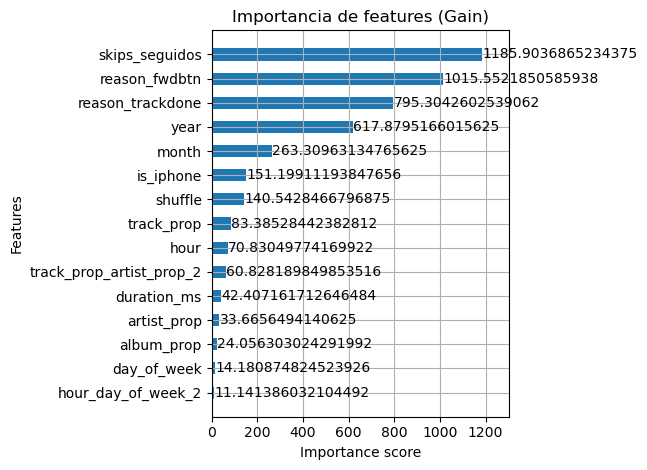

In [238]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [ ]:
# Predecimos sobre el conjunto de validación
best = clf_xgb.best_iteration
print(best)

prediccion_val = clf_xgb.predict_proba(val_data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']))[:, 1]
auc = roc_auc_score(val_data['TARGET'], prediccion_val)
print(f"AUC-ROC: {auc:.4f}")

99
AUC-ROC: 0.9355


In [236]:
prediccion_submmit = clf_xgb.predict_proba(submission.drop(columns=['Unnamed: 0', 'ts', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']))[:, 1]

In [237]:
results = pd.DataFrame({'ID': submission['Unnamed: 0'], 'TARGET': prediccion_submmit})
results = results.set_index('ID').loc[submission_aux['Unnamed: 0']].reset_index()
results.to_csv('submission14.csv', index=False)

In [ ]:
data = data.sort_values('ts').reset_index(drop=True)
data


,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,shuffle,TARGET,hour,day_of_week,month,year,is_iphone
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,fwdbtn,True,True,18,4,6,14,1
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,NaN,False,True,20,6,6,14,1
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,fwdbtn,False,True,20,6,6,14,1
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,fwdbtn,False,True,20,6,6,14,1
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,NaN,False,True,21,3,9,14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,74911,2024-05-23 17:24:56+00:00,The Tide Is High,Blondie,Atomic/Atomix,spotify:track:52Rp3xBJFYYdmpgzDy0Quf,trackdone,True,False,17,3,5,24,1
100140,74912,2024-05-23 17:28:33+00:00,The Less I Know The Better,Tame Impala,Currents,spotify:track:6K4t31amVTZDgR3sKmwUJJ,trackdone,True,False,17,3,5,24,1
100141,74913,2024-05-23 23:44:01+00:00,Pink + White,Frank Ocean,Blonde,spotify:track:3xKsf9qdS1CyvXSMEid6g8,trackdone,True,False,23,3,5,24,1
100142,74914,2024-05-23 23:50:25+00:00,Still Got The Blues,Gary Moore,Still Got The Blues,spotify:track:0DnGfA1r8pAssJCuq4ojla,clickrow,True,False,23,3,5,24,1


In [ ]:
data['reason_start'] = data['reason_start'].apply(simplify_reason)
data_encoded_reasons = pd.get_dummies(data['reason_start'], prefix='reason')
data_encoded_reasons = data_encoded_reasons[['reason_fwdbtn', 'reason_trackdone', 'reason_other']]

# # convertir a entero los bools

for col in train_encoded_reasons.columns:
    data_encoded_reasons[col] = data_encoded_reasons[col].astype(int)

# # Concatenar al DataFrame original

data = pd.concat([data.reset_index(drop=True), data_encoded_reasons.reset_index(drop=True)], axis=1)
data = data.drop(columns=['reason_start', 'reason_other'])

In [ ]:
data['duration_ms'] = data['spotify_track_uri'].apply(get_duration)

In [ ]:
data['track_prop'] = data.groupby('master_metadata_track_name')['master_metadata_track_name'].transform('count')/len(data)
data['artist_prop'] = data.groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].transform('count')/len(data)
data['album_prop'] = data.groupby('master_metadata_album_album_name')['master_metadata_album_album_name'].transform('count')/len(data)


In [ ]:
data = comb_polinom(data, ['hour', 'day_of_week'])

In [ ]:
calculate_skips_seguidos(data)

In [ ]:
data

,Unnamed: 0,ts,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,shuffle,TARGET,hour,day_of_week,...,year,is_iphone,reason_fwdbtn,reason_trackdone,duration_ms,track_prop,artist_prop,album_prop,hour day_of_week,skips_seguidos
0,74917,2014-06-27 18:01:16+00:00,Algo Demencial,Los Tipitos,Push,spotify:track:0rqD0zvqI4GrvyUxyQ7Ij3,True,True,18,4,...,14,1,1,0,344466.0,0.000010,0.002067,0.000679,72.0,0
1,74918,2014-06-29 20:10:10+00:00,Iron Man - Live,Black Sabbath,Past Lives,spotify:track:1XtZ3GROvmy4JrT6uMvsD8,False,True,20,6,...,14,1,0,0,385880.0,0.000020,0.000429,0.000020,120.0,0
2,74919,2014-06-29 20:10:54+00:00,Sultans Of Swing,Dire Straits,Dire Straits,spotify:track:3LTMnFa0hhwisyq6ILahyj,False,True,20,6,...,14,1,1,0,348624.0,0.000389,0.000869,0.000310,120.0,1
3,74920,2014-06-29 20:11:16+00:00,Fortunate Son,Creedence Clearwater Revival,Willy And The Poor Boys,spotify:track:7I2lPuuiOkpKtZlhr4zUpT,False,True,20,6,...,14,1,1,0,140773.0,0.000399,0.001238,0.000669,120.0,2
4,74921,2014-09-04 21:46:24+00:00,"Comptine d'un autre été, l'après-midi",Yann Tiersen,Amelie from Montmartre,spotify:track:2AkcjsKlRbIBYGAgpQVFii,False,True,21,3,...,14,1,0,0,140733.0,0.000020,0.000020,0.000020,63.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100139,74911,2024-05-23 17:24:56+00:00,The Tide Is High,Blondie,Atomic/Atomix,spotify:track:52Rp3xBJFYYdmpgzDy0Quf,True,False,17,3,...,24,1,0,1,232733.0,0.000409,0.000759,0.000419,51.0,0
100140,74912,2024-05-23 17:28:33+00:00,The Less I Know The Better,Tame Impala,Currents,spotify:track:6K4t31amVTZDgR3sKmwUJJ,True,False,17,3,...,24,1,0,1,216320.0,0.001907,0.002277,0.002087,51.0,0
100141,74913,2024-05-23 23:44:01+00:00,Pink + White,Frank Ocean,Blonde,spotify:track:3xKsf9qdS1CyvXSMEid6g8,True,False,23,3,...,24,1,0,1,184516.0,0.000040,0.000260,0.000050,69.0,0
100142,74914,2024-05-23 23:50:25+00:00,Still Got The Blues,Gary Moore,Still Got The Blues,spotify:track:0DnGfA1r8pAssJCuq4ojla,True,False,23,3,...,24,1,0,0,370866.0,0.000070,0.000300,0.000110,69.0,0


In [ ]:
clf_xgb.fit(data.drop(columns=['Unnamed: 0', 'ts','TARGET', 'master_metadata_track_name', 'master_metadata_album_artist_name', 'master_metadata_album_album_name', 'spotify_track_uri']),
                data['TARGET'],
                verbose=True
                )

ValueError: Must have at least 1 validation dataset for early stopping.